In [1]:
import sys, os

import numpy as np
import scipy as sp

import matplotlib.pyplot as plt

import illustris_python as il

In [2]:
# Illustris data directory
basePath = 'TNG100-1/output/'

# Hubble parameter
h = 0.704

# Load FoF group catalog
group_fields = ['Group_M_Crit200', 'GroupBHMass']
groups = il.groupcat.loadHalos(basePath, 99, fields=group_fields)

# Load Subfind group catalog
subhalo_fields = ['SubhaloMass', 'SubhaloBHMass', 'SubhaloMassType', 'SubhaloVelDisp', 'SubhaloSFRinRad']
subhalos = il.groupcat.loadSubhalos(basePath, 99, fields=subhalo_fields)

## Step 1
After identifying the data columns you wish to use, plot the relationship between dark matter halo mass (x-axis) and black hole mass (y-axis) for both subhalo (SubFind) and group (FoF) quantities. These plots must be included in the assignment you turn in, in addition to a short description of which data columns you used and why. If you performed any additional data cleaning or alteration you should summarize it here as well. Given the data volume you should think about how to present this data most clearly.

DescribeResult(nobs=np.int64(4371211), minmax=(np.float32(1.1782911e+07), np.float32(3.903116e+14)), mean=np.float32(5.6582743e+09), variance=np.float32(2.2964793e+23), skewness=np.float32(inf), kurtosis=np.float32(nan))
DescribeResult(nobs=np.int64(4371211), minmax=(np.float32(0.0), np.float32(1.1908019e+10)), mean=np.float32(351537.03), variance=np.float32(3.6038876e+14), skewness=np.float32(239.35983), kurtosis=np.float32(inf))
DescribeResult(nobs=np.int64(6291349), minmax=(np.float32(0.0), np.float32(3.667457e+14)), mean=np.float32(3.142935e+09), variance=np.float32(1.4213575e+23), skewness=np.float32(inf), kurtosis=np.float32(nan))
DescribeResult(nobs=np.int64(6291349), minmax=(np.float32(0.0), np.float32(3.6044644e+10)), mean=np.float32(244246.9), variance=np.float32(1.2163667e+15), skewness=np.float32(537.7445), kurtosis=np.float32(inf))


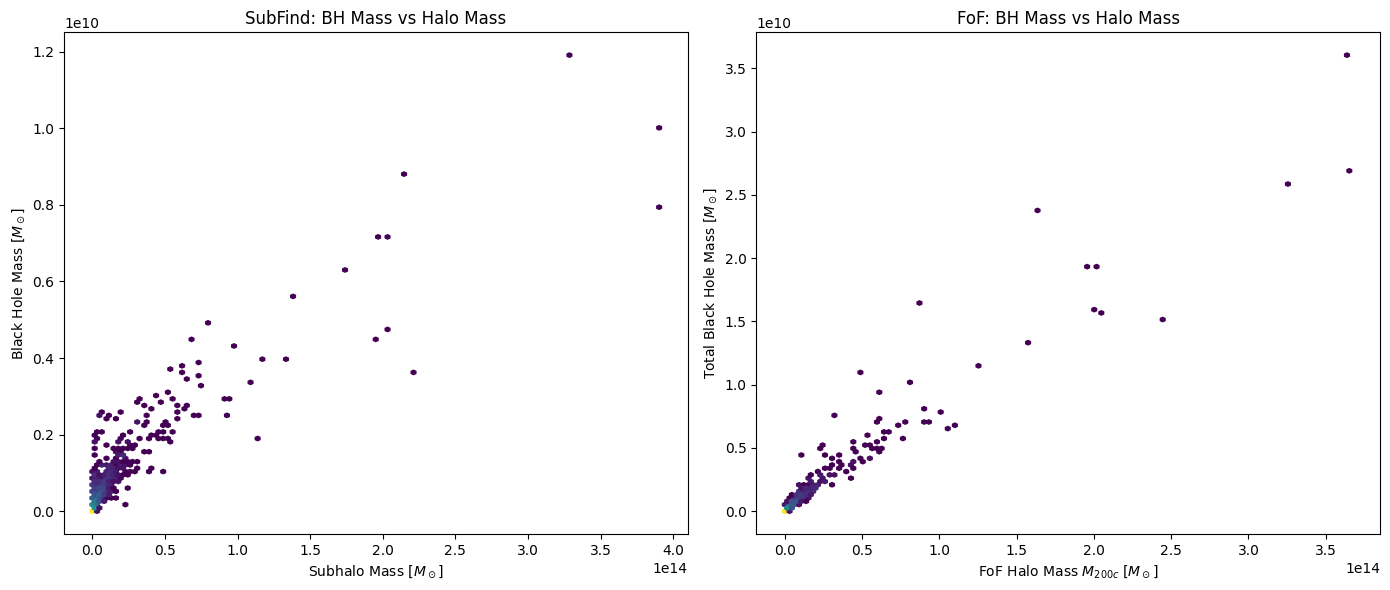

In [4]:
# Convert mass
subhalo_mass = subhalos['SubhaloMass'] * 1e10 / h
print(sp.stats.describe(subhalo_mass))
subhalo_bh_mass = subhalos['SubhaloBHMass'] * 1e10 / h
print(sp.stats.describe(subhalo_bh_mass))

group_mass = groups['Group_M_Crit200'] * 1e10 / h
print(sp.stats.describe(group_mass))
group_bh_mass = groups['GroupBHMass'] * 1e10 / h
print(sp.stats.describe(group_bh_mass))

# No negative numbers so no data cleaning needed

fig, ax = plt.subplots(1, 2, figsize=(14,6))

# ---- SubFind ----
# ax[0].scatter(subhalo_mass, subhalo_bh_mass, s=1)
ax[0].hexbin(subhalo_mass, subhalo_bh_mass, gridsize=120, bins='log')   # AI suggested to use hexbin for better visualization of dense regions
ax[0].set_xlabel('Subhalo Mass [$M_\\odot$]')
ax[0].set_ylabel('Black Hole Mass [$M_\\odot$]')
ax[0].set_title('SubFind: BH Mass vs Halo Mass')

# Column justification:
#   SubhaloMass: total bound mass of each galaxy-scale halo
#   SubhaloBHMass: total BH mass within the subhalo
#   these probe the BH–halo relation at the galaxy level

# ---- FoF ----
# ax[1].scatter(group_mass, group_bh_mass, s=1)
ax[1].hexbin(group_mass, group_bh_mass, gridsize=120, bins='log')
ax[1].set_xlabel('FoF Halo Mass $M_{200c}$ [$M_\\odot$]')
ax[1].set_ylabel('Total Black Hole Mass [$M_\\odot$]')
ax[1].set_title('FoF: BH Mass vs Halo Mass')

# Column justification:
#   Group_M_Crit200: dark matter halo mass within R200
#   GroupBHMass: total BH mass across entire FoF halo
#   these probe the BH–halo relation at the full halo scale

plt.tight_layout()
plt.show()

# Step 2
Come up with a reasonable physical equation relating the black hole mass to the halo mass. You do not need to estimate physical constants, but you should explain why you chose the scaling that you did. Hypothesize as to the physical mechanisms that could give rise to such a relationship between these parameters.

# Step 3
Determine if there is a difference in the relation between the SubFind and FoF catalogs. Form a
hypothesis as to why there should or should not be a difference and include it in your write-up.

# Step 4
Plot the relation between galaxy stellar mass and black hole mass and comment on it briefly. Is it
tighter or more scattered than the halo mass – black hole mass relation? Is the correlation what you
expected? And so on. You may provide other supporting plots here if you wish.

# Step 5
Explore the data columns to identify another column that is correlated with black hole mass. Plot
the relation and hypothesize as to the origin of the correlation.

# Step 6
Comment on any limitations of the data products that you believe may impact the above
relations. If your work were to be published in a journal paper, what concerns would you have?

# ASTR 5140 Only

# Step 1
Make cuts on the halo catalog to identify a list of subhalos with well-defined black hole masses and velocity dispersions (SubFind field [`SubhaloVelDisp`]). Summarize your cuts and plot this relation. Fit a model of your own design to this relation via least-squares or other similar technique. Comment on your result.

# Step 2
Review section 14.2 of Galaxy Formation and Evolution by Mo, van den Bosch & White – see the “background” section above for a link to read the ebook on the UVA library website. Assume all black holes accrete at their Eddington luminosities and compute the corresponding AGN luminosities for the galaxies you selected from IllustrisTNG.

a. Calculate and plot the average AGN luminosity as a function halo mass.

b. Plot the distribution (histogram) of AGN luminosities.

c. What fraction of halos in TNG100-1 have Eddington AGN luminosities (as computed above) greater than 1.28e46 ergs / s?

# Step 3 
Now examine the actual black hole accretion rates as listed in the TNG catalogs.

a. Make a plot comparing the black hole accretion rates in the TNG catalogs to the Eddington mass accretion rate as a function of halo mass Discuss whether the TNG results are consistent with Eddington accretion.

b. Let the efficiency of converting mass accretion into luminosity (εr in the reading) be 0.1. Compute AGN luminosities for the galaxies you selected from IllustrisTNG using the black hole accretion rates in the TNG catalogs. Plot the average AGN luminosity calculated this way as a function of halo mass and compare to the same plot you made in 2a) above assuming Eddington mass accretion. Plot the distribution of AGN luminosities and compare to the plot from 2b) above. What fraction of halos in TNG100-1 have AGN luminosities greater than 1.28e46 ergs / s when using the TNG mass accretion rates? How does this compare to your answer from 2c) where you assumed Eddington accretion? Comment on how the assumption of Eddington accretion rates may affect predictions for the frequency of observing bright quasars.